In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Exercício 1: Teorema Central do Limite

Considere o **Teorema Central do Limite (TCL)**. Sejam $X_1, \ldots, X_n$ variáveis aleatórias i.i.d., com média $\mu$ e variância finita $\sigma^2$. Então,

$$
\frac{\sqrt{n}(\bar{X}_n - \mu)}{\sigma}
\xrightarrow{d}
N(0,1),
$$

quando $n \to \infty$.

O objetivo deste exercício é verificar empiricamente o comportamento descrito pelo TCL para diferentes distribuições e diferentes valores de $n$.

1. Considere as seguintes distribuições para $X$:

   * Uniforme;
   * Bernoulli;
   * Geométrica;
   * Poisson.

   Para cada distribuição, escolha diferentes valores de $n$ e gere $M = 5000$ realizações da variável aleatória

   $$
   Z_n = \frac{\sqrt{n}(\bar{X}_n - \mu)}{\sigma}.
   $$

   Compare o comportamento da distribuição de $Z_n$ conforme o valor de $n$ aumenta.

In [2]:
def normalizar_amostra(amostra, n, mi, sigma2):
    normal = np.sqrt(n)*(np.mean(amostra,axis=1)-mi)/np.sqrt(sigma2)
    return normal

### Uniforme


In [3]:
n = 1000
M = 5000

In [4]:
amostras_uniformes = np.random.uniform(size=(M,n))
amostra_normalizada = normalizar_amostra(amostras_uniformes, n, 0.5, 1/12)

In [28]:
df = pd.DataFrame(amostras_uniformes)
df

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
0,0.707414,0.613847,0.564164,0.036027,0.406620,0.360903,0.804282,0.138365,0.153447,0.255898,...,0.810734,0.673897,0.513110,0.816472,0.013065,0.570587,0.568588,0.127166,0.554887,0.992414
1,0.435365,0.388841,0.378657,0.000530,0.885439,0.289620,0.509021,0.203945,0.819857,0.008091,...,0.545096,0.441107,0.379988,0.525942,0.362635,0.882565,0.245743,0.144870,0.106742,0.857636
2,0.055679,0.631575,0.898336,0.090596,0.513517,0.065755,0.143323,0.949603,0.138299,0.950214,...,0.851137,0.793202,0.869599,0.711386,0.354267,0.648086,0.124086,0.481682,0.115720,0.166430
3,0.394416,0.311006,0.920283,0.248340,0.051876,0.070906,0.116698,0.999941,0.245677,0.001177,...,0.502148,0.261852,0.876164,0.631967,0.477379,0.033363,0.822082,0.897519,0.296846,0.664142
4,0.490542,0.668362,0.720320,0.779925,0.692647,0.802286,0.300936,0.153949,0.077797,0.824863,...,0.251395,0.984562,0.569026,0.863167,0.464940,0.815684,0.403295,0.882525,0.976183,0.170020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,0.668040,0.459927,0.119311,0.315293,0.954932,0.221812,0.964786,0.442985,0.290172,0.873291,...,0.694142,0.204761,0.307099,0.449881,0.930049,0.938391,0.622109,0.024889,0.324201,0.656934
4996,0.167412,0.707256,0.899398,0.771886,0.887655,0.114144,0.681175,0.022039,0.596733,0.956351,...,0.555105,0.484425,0.901318,0.896676,0.027071,0.538680,0.785912,0.412506,0.816689,0.161860
4997,0.737919,0.708334,0.189935,0.157965,0.188200,0.176699,0.199698,0.139661,0.945002,0.930447,...,0.712023,0.243311,0.708966,0.440939,0.502796,0.004945,0.886476,0.938736,0.238684,0.859430
4998,0.334213,0.517275,0.996141,0.104027,0.757575,0.373300,0.632108,0.236849,0.278913,0.974332,...,0.170646,0.829169,0.143917,0.585332,0.136961,0.666531,0.602044,0.646679,0.185128,0.284787


(array([  11.,   64.,  315.,  828., 1392., 1324.,  749.,  253.,   52.,
          12.]),
 array([-3.57153281, -2.84513531, -2.11873782, -1.39234032, -0.66594283,
         0.06045466,  0.78685216,  1.51324965,  2.23964715,  2.96604464,
         3.69244214]),
 <BarContainer object of 10 artists>)

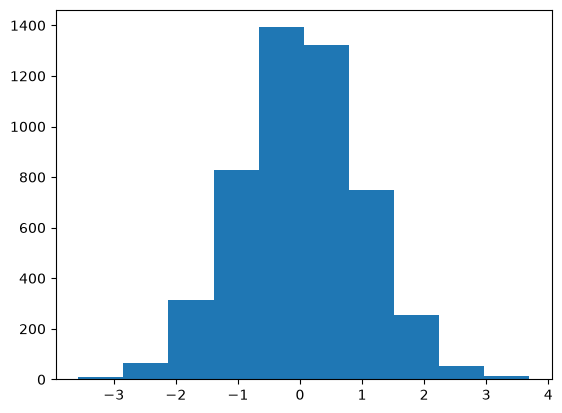

In [5]:
plt.hist(amostra_normalizada)

### Bernoulli

In [8]:
p = 0.5

amostra_bernoulli = amostras_uniformes < p

In [9]:
amostra_normalizada_bernoullis = normalizar_amostra(amostra_bernoulli, n, 0.5, 0.25)

(array([  13.,   56.,  310.,  790., 1282., 1316.,  827.,  312.,   80.,
          14.]),
 array([-3.54175098, -2.84604989, -2.15034881, -1.45464772, -0.75894664,
        -0.06324555,  0.63245553,  1.32815662,  2.0238577 ,  2.71955879,
         3.41525987]),
 <BarContainer object of 10 artists>)

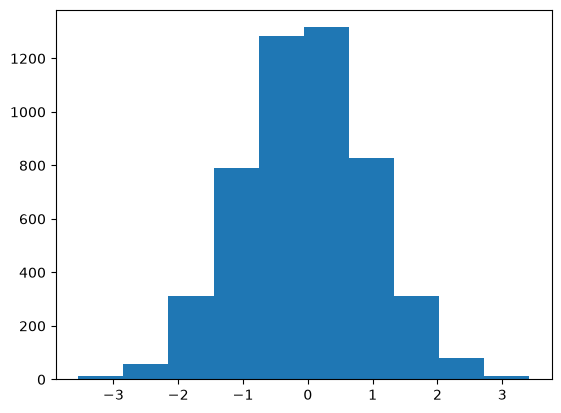

In [10]:
plt.hist(amostra_normalizada_bernoullis)

### Geométrica

In [12]:
p = 0.5
amostras_geometricas = np.floor(np.log(1-amostras_uniformes)/np.log(1-p)) + 1


In [13]:
amostras_geometricas_normalizadas = normalizar_amostra(amostras_geometricas, n, 2, 2)

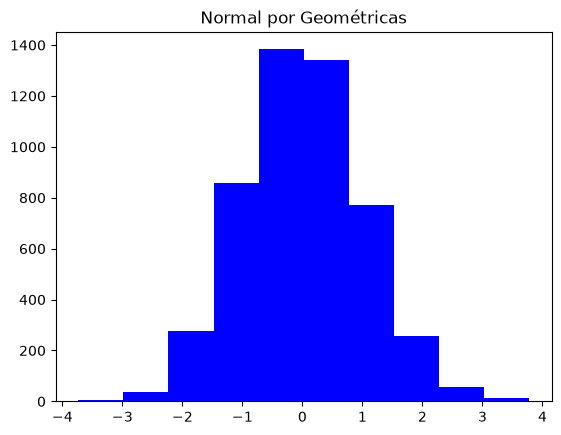

In [15]:
plt.hist(amostras_geometricas_normalizadas, color="blue")
plt.title("Normal por Geométricas")
plt.show()

### Poisson

In [31]:
lmbd = 5
amostras_poisson = []
for _ in tqdm(range(M), desc='Gerando Amostras'):
    amostra_1_poisson = []
    for _ in range(n):
        u = np.random.uniform()
        i = 0
        p0 = np.exp(-lmbd)
        F = p0
        while u > F:
            i += 1
            p0 *= (lmbd/i)
            F += p0
        amostra_1_poisson.append(i)
    amostras_poisson.append(amostra_1_poisson)


Gerando Amostras: 100%|██████████| 5000/5000 [02:16<00:00, 36.53it/s]


(array([5.000e+00, 2.300e+01, 2.150e+02, 6.930e+02, 1.511e+03, 1.554e+03,
        7.680e+02, 2.060e+02, 2.400e+01, 1.000e+00]),
 array([-4.24264069, -3.39552676, -2.54841284, -1.70129892, -0.85418499,
        -0.00707107,  0.84004286,  1.68715678,  2.5342707 ,  3.38138463,
         4.22849855]),
 <BarContainer object of 10 artists>)

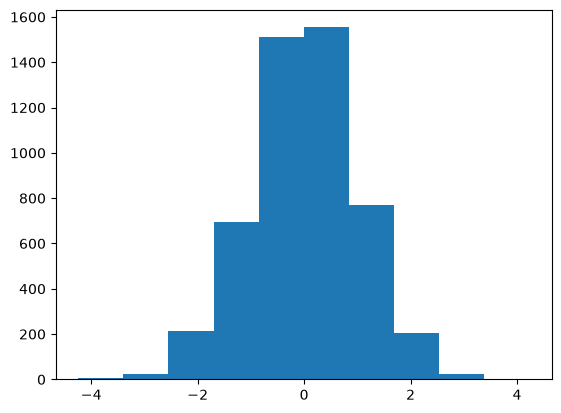

In [33]:
amostra_poisson_normalizada = normalizar_amostra(amostras_poisson, n, 5, 5)
plt.hist(amostra_poisson_normalizada)

2. Para cada distribuição e para cada valor de $n$, construa um histograma das $M = 5000$ realizações de $Z_n$.

   Compare os histogramas obtidos com uma amostra de uma distribuição normal padrão $N(0,1)$ gerada diretamente pelo NumPy.

3. Analise os resultados obtidos e discuta:

   * como a aproximação pela distribuição normal muda conforme $n$ aumenta;
   * quais distribuições apresentam convergência mais rápida para a normal;
   * como o formato da distribuição original influencia a qualidade da aproximação para valores pequenos de $n$.

# Exercício 2: Aproximação de Poisson

Como vimos em sala, se$X_n \sim \operatorname{Binomial}(n,p_n),$ com $p_n = \frac{\lambda}{n},$ então, para $\lambda > 0$ fixo,

$$
X_n \xrightarrow{d} \operatorname{Poisson}(\lambda)
$$

quando $n \to \infty$.

Em outras palavras, quando $n$ aumenta e $p_n$ diminui de forma que $np_n = \lambda,$ a distribuição $\operatorname{Binomial}(n,p_n)$ se aproxima de uma distribuição $\operatorname{Poisson}(\lambda)$.

1. Fixe um valor de $\lambda$ e um tamanho de amostra $M$. Para diferentes valores de $n$:

   * defina $p_n = \lambda/n$;
   * gere uma amostra de tamanho $M$ de variáveis

   $$
   X_n \sim \operatorname{Binomial}\left(n,\frac{\lambda}{n}\right);
   $$

   * compare as distribuições obtidas para diferentes valores de $n$ e analise o efeito do aumento de $n$ na aproximação pela distribuição de Poisson.

2. Para verificar a qualidade da aproximação, compare as amostras obtidas pelo método binomial com:

   * uma amostra de tamanho $M$ gerada diretamente por `numpy.random.poisson`;
   * uma amostra de tamanho $M$ de variáveis $\operatorname{Poisson}(\lambda)$ geradas utilizando o **método recursivo**.

3. Para cada método, construa histogramas ou gráficos de frequências e compare as distribuições empíricas obtidas.

4. Compare também o **tempo de execução** dos dois métodos:

   * aproximação por $\operatorname{Binomial}(n,\lambda/n)$;
   * geração de Poisson pelo método da inversão.

5. Discuta os resultados obtidos, considerando:

   * como o valor de $n$ influencia a qualidade da aproximação binomial-Poisson;
   * se as distribuições empíricas produzidas pelos três métodos são semelhantes;
   * as diferenças de tempo de execução entre os métodos;
   * as vantagens e desvantagens de cada método de geração.